In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from timeit import default_timer as timer

import gropt
# Updated to use the accelerated parallel search
# from gropt.diff_v2 import diff_min_TE_parallel as diff_min_TE
# from gropt.diff import diff_min_TE
from gropt.diff_v2 import diff_min_TE
gropt.setup_logging(level=3)

# Load scanner geometry rules
[asc_file, extra] = gropt.readasc.readasc(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
forbidden_frequency = gropt.readasc.asc_to_acoustic_resonances(asc_file)
[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')

print("Safe Parameters:", safe_params)
print("Safe Parameters (Cardiac):", safe_params_cardiac)

forbidden_frequencies = [f['frequency'] for f in forbidden_frequency]
forbidden_bandwidths = [f['bandwidth'] for f in forbidden_frequency]

print("Forbidden Frequencies (Hz):", forbidden_frequencies)
print("Forbidden Bandwidths (Hz):", forbidden_bandwidths)

Safe Parameters: {'tau1': array([0.0006  , 0.000889, 0.000839]), 'tau2': array([0.012, 0.012, 0.012]), 'tau3': array([0.0002  , 0.000193, 0.0002  ]), 'a1': array([0.412, 0.439, 0.3  ]), 'a2': array([0.2  , 0.3  , 0.273]), 'a3': array([0.388, 0.261, 0.427]), 'stim_limit': array([37.077, 22.988, 32.209]), 'g_scale': array([0.3324, 0.3369, 0.3059])}
Safe Parameters (Cardiac): {'tau1': array([0.0026, 0.0026, 0.0026]), 'tau2': array([0.0018, 0.0018, 0.0018]), 'tau3': array([0.001, 0.001, 0.001]), 'a1': array([0.743, 0.743, 0.743]), 'a2': array([0.257, 0.257, 0.257]), 'a3': array([0, 0, 0]), 'stim_limit': array([17.15, 17.38, 15.78]), 'g_scale': array([0.3324, 0.3369, 0.3059])}
Forbidden Frequencies (Hz): [576, 1113]
Forbidden Bandwidths (Hz): [100, 344]


In [ ]:
# Hardware Limits
dt = 40e-6
gmax = 200*1e-3  # 200 mT/m
smax = 200       # 200 T/m/s

# Sequence timing geometry
T_90 = 3e-3 # s
T_180 = 6e-3 # s
T_readout = 16e-3 # s
b = 1000 # s/mm^2

print("Configuring parameters for Baseline Comparison...")
search_params_base = {
    'bvalue': b,                 
    'dt': dt,                    
    'T_90': T_90,                
    'T_180': T_180,              
    'T_readout': T_readout,      
    'gmax': gmax,                
    'smax': smax,                
    'MMT': 1,                    
    'pns_lim': 0.7,
    'pns_params': safe_params,
    'cns_lim': 0.7,
    'cns_params': safe_params_cardiac,
    'tv_lam': 1e-18,
    # 'tv_lam': 1e-16,
    'tv_weight': 5e5,
    # 'tv2_lam': 0,             
    'identity_lam': 1e-5,
}

search_params_ac = search_params_base.copy()
search_params_ac['acoustic'] = {
    'freqs': forbidden_frequencies,
    'bws': forbidden_bandwidths
}
# search_params_ac['tv_lam'] = 1e-1
# search_params_ac['tv_weight'] = 1
# search_params_ac['tv2_lam'] = 1e1

Configuring parameters for Baseline Comparison...


In [3]:
print("Running Baseline GrOpt...")
best_TE_base, result_base = diff_min_TE(search_params_base, target_bval=b)
print(f"Base TE: {best_TE_base*1e3:.2f} ms")
print(f"Base b-value: {result_base.bvalue:.2f} s/mm^2")
grad_base = result_base.X

print("\nRunning Acoustically Constrained GrOpt...")
best_TE_ac, result_ac = diff_min_TE(search_params_ac, target_bval=b)
print(f"Acoustic TE: {best_TE_ac*1e3:.2f} ms")
print(f"Acoustic b-value: {result_ac.bvalue:.2f} s/mm^2")
grad_ac = result_ac.X

|    ERROR |  Large values detected in Xhat at iteration 20. Stopping solver.


Running Baseline GrOpt...
Searching TE: 
[TE: 87.00, b: 9463.321605085795] 
[TE: 70.50, b: 3432.966162983313] 

|    ERROR |  Large values detected in Xhat at iteration 21. Stopping solver.



![TE: 62.25, b: 1496.2727530362642] 

|    ERROR |  Large values detected in Xhat at iteration 23. Stopping solver.


...

Base TE: 67.73 ms
Base b-value: 825.37 s/mm^2

Running Acoustically Constrained GrOpt...


|    ERROR |  Large values detected in Xhat at iteration 480. Stopping solver.
|    ERROR |  Large values detected in Xhat at iteration 21. Stopping solver.
|    ERROR |  Large values detected in Xhat at iteration 18. Stopping solver.
|    ERROR |  Large values detected in Xhat at iteration 13. Stopping solver.


ERROR: Max TE 0.12 did not converge or was too low bvalue: False  54758.4991704198
Searching TE: 
[TE: 87.00, b: 8561.516854087979] 

|    ERROR |  Large values detected in Xhat at iteration 406. Stopping solver.



![TE: 70.50, b: 4970.2026880960375] 
[TE: 78.75, b: 4874.629542666744] 
[TE: 74.62, b: 3938.282197429326] 
[TE: 72.56, b: 3496.133459396224] 
[TE: 71.53, b: 2187.4342204502473] 
[TE: 71.02, b: 3013.540446715626] 
[TE: 70.76, b: 2881.788573515246] 
[TE: 70.63, b: 2864.9472895260506] 
[TE: 70.56, b: 2981.1113687404063] Done!
Refining at Best TE: 70.56 ms with exact target B-value...
Acoustic TE: 70.56 ms
Acoustic b-value: 1000.97 s/mm^2


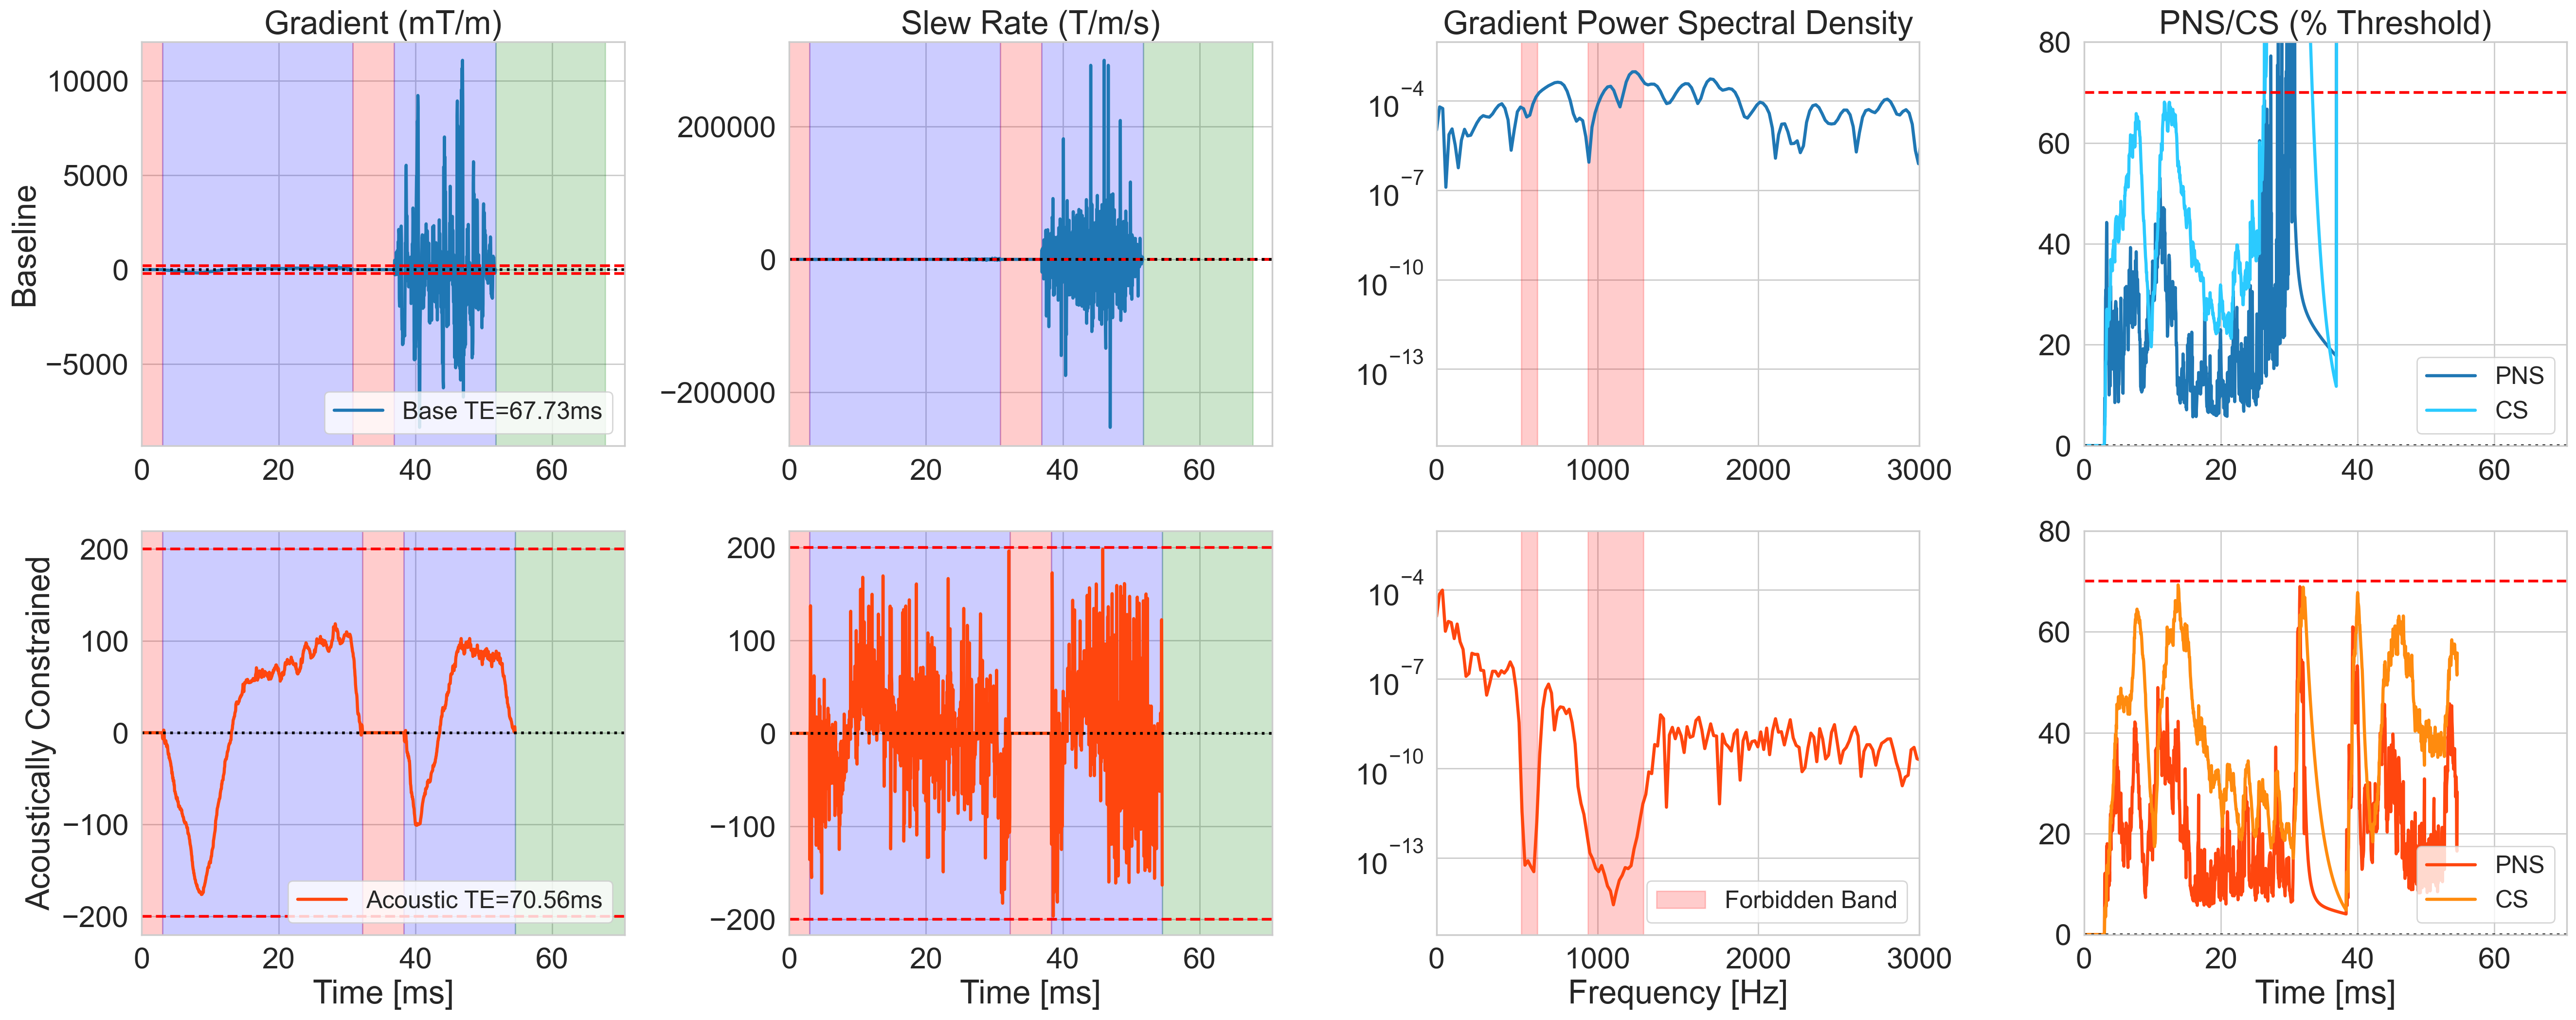

In [4]:
# PSD setup
fs = 1.0 / dt
nperseg_base = min(2048, len(grad_base))
xf_base, psd_base = welch(grad_base, fs=fs, window="hann", nperseg=nperseg_base, noverlap=nperseg_base//2, scaling="density")

nperseg_ac = min(2048, len(grad_ac))
xf_ac, psd_ac = welch(grad_ac, fs=fs, window="hann", nperseg=nperseg_ac, noverlap=nperseg_ac//2, scaling="density")

# SAFE setup
safe_base = gropt.gropt_wrapper.get_SAFE(grad_base, dt, new_first_axis=0, demo_params=False, safe_params=safe_params)
safe_cardiac_base = gropt.gropt_wrapper.get_SAFE(grad_base, dt, new_first_axis=0, demo_params=False, safe_params=safe_params_cardiac)

safe_ac = gropt.gropt_wrapper.get_SAFE(grad_ac, dt, new_first_axis=0, demo_params=False, safe_params=safe_params)
safe_cardiac_ac = gropt.gropt_wrapper.get_SAFE(grad_ac, dt, new_first_axis=0, demo_params=False, safe_params=safe_params_cardiac)

# Plot formatting mirroring ISMRM
sns.set_theme(font_scale=2.0, style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(27, 11), dpi=200)
colors = ['#1f77b4', "#FF460E"]  # Blue for baseline, Orange for acoustic

# Row 1: Baseline GrOpt
time_base = np.arange(len(grad_base)) * dt * 1e3
axes[0, 0].plot(time_base, grad_base*1000, linewidth=2.33, color=colors[0], label=f'Base TE={best_TE_base*1e3:.2f}ms')
axes[0, 1].plot(time_base[:-1], np.diff(grad_base)/dt, linewidth=2.33, color=colors[0])
axes[0, 2].semilogy(xf_base, psd_base, linewidth=2.33, color=colors[0])
axes[0, 3].plot(time_base, safe_base*100, linewidth=2.33, color=colors[0], label='PNS')
axes[0, 3].plot(time_base, safe_cardiac_base*100, linewidth=2.33, color="#2bcaff", label='CS')

# Row 2: Acoustic GrOpt
time_ac = np.arange(len(grad_ac)) * dt * 1e3
axes[1, 0].plot(time_ac, grad_ac*1000, linewidth=2.33, color=colors[1], label=f'Acoustic TE={best_TE_ac*1e3:.2f}ms')
axes[1, 1].plot(time_ac[:-1], np.diff(grad_ac)/dt, linewidth=2.33, color=colors[1])
axes[1, 2].semilogy(xf_ac, psd_ac, linewidth=2.33, color=colors[1])
axes[1, 3].plot(time_ac, safe_ac*100, linewidth=2.33, color=colors[1], label='PNS')
axes[1, 3].plot(time_ac, safe_cardiac_ac*100, linewidth=2.33, color="#FF8B0E", label='CS')

# Highlight Acoustic Frequency Bands
for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
    axes[0, 2].axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red")
    axes[1, 2].axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)

# Formatting hardware thresholds
for i in range(2):
    axes[i, 0].axhline(gmax*1000, color='red', linestyle='--', linewidth=2)
    axes[i, 0].axhline(-gmax*1000, color='red', linestyle='--', linewidth=2)
    axes[i, 0].axhline(0, color='black', linestyle=':', linewidth=2)
    axes[i, 0].set_xlim([0, max(best_TE_ac, best_TE_base)*1e3])
    axes[i, 1].axhline(smax, color='red', linestyle='--', linewidth=2)
    axes[i, 1].axhline(-smax, color='red', linestyle='--', linewidth=2)
    axes[i, 1].axhline(0, color='black', linestyle=':', linewidth=2)
    axes[i, 1].set_xlim([0, max(best_TE_ac, best_TE_base)*1e3])
    axes[i, 2].set_xlim([0, 3000])
    axes[i, 2].set_ylim([min(psd_base.min(), psd_ac.min())*0.1, max(psd_base.max(), psd_ac.max())*10])
    axes[i, 3].axhline(search_params_base['pns_lim']*100, color='red', linestyle='--', linewidth=2)
    axes[i, 3].axhline(0, color='black', linestyle=':', linewidth=2)
    axes[i, 3].set_xlim([0, max(best_TE_ac, best_TE_base)*1e3])
    axes[i, 3].set_ylim([0, 80])


for i in range(2):
    axes[0, i].axvspan(0, search_params_base['T_90']*1e3, alpha=0.2, color='red')
    axes[0, i].axvspan(search_params_base['T_90']*1e3, (best_TE_base-search_params_base['T_180'])/2*1e3, alpha=0.2, color='blue')
    axes[0, i].axvspan((best_TE_base-search_params_base['T_180'])/2*1e3, (best_TE_base+search_params_base['T_180'])/2*1e3, alpha=0.2, color='red')
    axes[0, i].axvspan((best_TE_base+search_params_base['T_180'])/2*1e3, time_base[-1], alpha=0.2, color='blue')
    axes[0, i].axvspan(time_base[-1], best_TE_base*1e3, alpha=0.2, color='green')
    
    axes[1, i].axvspan(0, search_params_ac['T_90']*1e3, alpha=0.2, color='red')
    axes[1, i].axvspan(search_params_ac['T_90']*1e3, (best_TE_ac-search_params_ac['T_180'])/2*1e3, alpha=0.2, color='blue')
    axes[1, i].axvspan((best_TE_ac-search_params_ac['T_180'])/2*1e3, (best_TE_ac+search_params_ac['T_180'])/2*1e3, alpha=0.2, color='red')
    axes[1, i].axvspan((best_TE_ac+search_params_ac['T_180'])/2*1e3, time_ac[-1], alpha=0.2, color='blue')
    axes[1, i].axvspan(time_ac[-1], best_TE_ac*1e3, alpha=0.2, color='green')



axes[0,0].set_title('Gradient (mT/m)')
axes[0,1].set_title('Slew Rate (T/m/s)')
axes[0,2].set_title('Gradient Power Spectral Density')
axes[0,3].set_title('PNS/CS (% Threshold)')

axes[0,0].set_ylabel('Baseline')
axes[1,0].set_ylabel('Acoustically Constrained')

for j in range(4):
    axes[1, j].set_xlabel('Time [ms]' if j != 2 else 'Frequency [Hz]')

axes[0,0].legend(loc='lower right', fontsize=18)
axes[1,0].legend(loc='lower right', fontsize=18)
axes[1,2].legend(loc='lower right', fontsize=18)
axes[0,3].legend(loc='lower right', fontsize=18)
axes[1,3].legend(loc='lower right', fontsize=18)

plt.tight_layout()
plt.show()